In [1]:
%matplotlib inline
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
import numpy

## Generative Adversarial Networks

In [ ]:
## ChatGPT example

In [ ]:
# 1. Imports and Setup

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
# ✅ 2. Hyperparameters

In [4]:
latent_dim = 100      # Size of the noise vector (input to Generator)
lr = 0.0002           # Learning rate
batch_size = 64
image_size = 28 * 28  # MNIST images are 28x28
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# ✅ 3. Data Loading (MNIST)

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1]
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|███████████████████████| 9912422/9912422 [00:01<00:00, 6403121.50it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|████████████████████████████| 28881/28881 [00:00<00:00, 220042.68it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|███████████████████████| 1648877/1648877 [00:00<00:00, 2228950.38it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████| 4542/4542 [00:00<00:00, 2806914.51it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



# ✅ 4. Generator Model

In [6]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, image_size),
            nn.Tanh()  # Output in [-1, 1]
        )

    def forward(self, z):
        return self.model(z)

## ✅ 5. Discriminator Model

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Output probability
        )

    def forward(self, x):
        return self.model(x)

## ✅ 6. Initialize Models and Optimizers

In [8]:
G = Generator().to(device)
D = Discriminator().to(device)

loss_fn = nn.BCELoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr)
optimizer_D = optim.Adam(D.parameters(), lr=lr)

## ✅ 7. Training Loop

In [9]:
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.view(-1, image_size).to(device)
        batch_size = real_imgs.size(0)

        # Real and Fake labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---- Train Discriminator ----
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = G(z)

        real_loss = loss_fn(D(real_imgs), real_labels)
        fake_loss = loss_fn(D(fake_imgs.detach()), fake_labels)
        d_loss = real_loss + fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # ---- Train Generator ----
        z = torch.randn(batch_size, latent_dim).to(device)
        fake_imgs = G(z)
        g_loss = loss_fn(D(fake_imgs), real_labels)  # Fool the discriminator

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}")

[Epoch 1/50] D_loss: 0.0063, G_loss: 6.2527
[Epoch 2/50] D_loss: 0.0001, G_loss: 10.3481
[Epoch 3/50] D_loss: 0.0001, G_loss: 9.8569
[Epoch 4/50] D_loss: 0.0000, G_loss: 11.3090
[Epoch 5/50] D_loss: 0.0000, G_loss: 11.1812
[Epoch 6/50] D_loss: 0.0000, G_loss: 12.7277
[Epoch 7/50] D_loss: 0.0000, G_loss: 14.0434
[Epoch 8/50] D_loss: 0.0000, G_loss: 14.7145
[Epoch 9/50] D_loss: 0.0000, G_loss: 15.2792
[Epoch 10/50] D_loss: 0.0000, G_loss: 15.7988
[Epoch 11/50] D_loss: 0.0000, G_loss: 79.8701
[Epoch 12/50] D_loss: 0.0000, G_loss: 79.5526
[Epoch 13/50] D_loss: 0.0000, G_loss: 79.4411
[Epoch 14/50] D_loss: 0.0000, G_loss: 79.2037
[Epoch 15/50] D_loss: 0.0000, G_loss: 79.2444
[Epoch 16/50] D_loss: 0.0000, G_loss: 79.0662
[Epoch 17/50] D_loss: 0.0000, G_loss: 78.9751
[Epoch 18/50] D_loss: 0.0000, G_loss: 78.8957
[Epoch 19/50] D_loss: 0.0000, G_loss: 78.8448
[Epoch 20/50] D_loss: 0.0000, G_loss: 78.9625
[Epoch 21/50] D_loss: 0.0000, G_loss: 78.7216
[Epoch 22/50] D_loss: 0.0000, G_loss: 78.6665

In [ ]:
## ✅ 8. Visualizing the Generated Images

In [11]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.


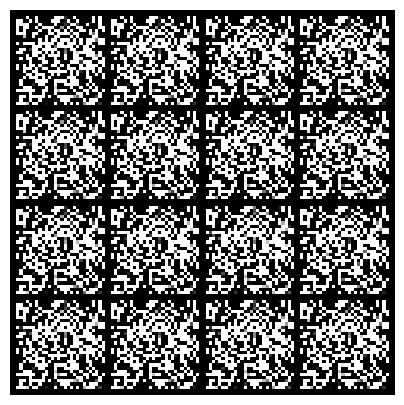

In [12]:
import matplotlib.pyplot as plt
import torchvision

def show_images(generator, n=16):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n, latent_dim).to(device)
        fake_imgs = generator(z).view(n, 1, 28, 28).cpu()
    grid = torchvision.utils.make_grid(fake_imgs, nrow=4, normalize=True)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid.permute(1, 2, 0).squeeze())
    plt.axis("off")
    plt.show()

show_images(G)